## 1: Imports e Setup

In [2]:
"""
Phase 1: Manual INT8 Quantization - Analysis Notebook
=====================================================
This notebook demonstrates the implementation and evaluation
of INT8 quantization from scratch (no frameworks).
"""

import sys
sys.path.append('../src')

import numpy as np
import matplotlib.pyplot as plt
import json
import os

# Import project modules
from model import SimpleMLP
from quantize import (
    quantize_symmetric, 
    quantize_asymmetric,
    QuantizedMLP,
    QuantizedMLP_Asymmetric
)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Paths
RESULTS_DIR = '../results'
PLOTS_DIR = '../plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

print("Setup complete.")

Setup complete.


## 2: Load Metrics

In [3]:
"""
Load pre-computed metrics from evaluation runs.
"""

# FP32 metrics
with open(f'{RESULTS_DIR}/float32/metrics.json', 'r') as f:
    metrics_fp32 = json.load(f)

# INT8 Symmetric metrics
with open(f'{RESULTS_DIR}/int8_symmetric/metrics.json', 'r') as f:
    metrics_int8_sym = json.load(f)

# Check if asymmetric exists
int8_asym_path = f'{RESULTS_DIR}/int8_asymmetric/metrics.json'
if os.path.exists(int8_asym_path):
    with open(int8_asym_path, 'r') as f:
        metrics_int8_asym = json.load(f)
else:
    metrics_int8_asym = None
    print("WARNING: Asymmetric metrics not found. Run evaluate_asymmetric.py first.")

print(f"FP32 Accuracy: {metrics_fp32['accuracy']:.2f}%")
print(f"INT8 Symmetric Accuracy: {metrics_int8_sym['int8_accuracy']:.2f}%")
print(f"Degradation: {metrics_int8_sym['degradation']:.2f}%")
print(f"Disagreements: {metrics_int8_sym['num_errors']}")

FP32 Accuracy: 97.60%
INT8 Symmetric Accuracy: 97.65%
Degradation: -0.05%
Disagreements: 13


## 3: Accuracy Comparison Bar Chart

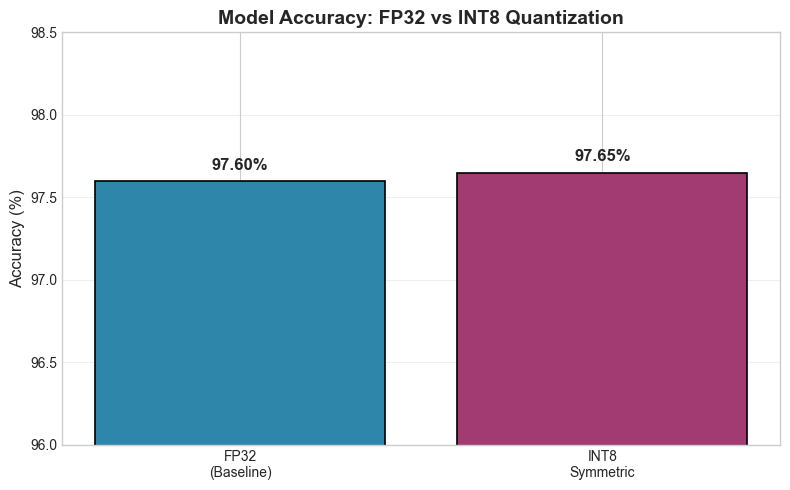

In [4]:
"""
Compare accuracy across quantization schemes.
"""

fig, ax = plt.subplots(figsize=(8, 5))

schemes = ['FP32\n(Baseline)', 'INT8\nSymmetric', 'INT8\nAsymmetric']
accuracies = [
    metrics_fp32['accuracy'],
    metrics_int8_sym['int8_accuracy'],
    metrics_int8_asym['int8_accuracy'] if metrics_int8_asym else 0
]

colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax.bar(schemes[:2 + (metrics_int8_asym is not None)], 
              accuracies[:2 + (metrics_int8_asym is not None)], 
              color=colors[:2 + (metrics_int8_asym is not None)],
              edgecolor='black',
              linewidth=1.2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.05,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Model Accuracy: FP32 vs INT8 Quantization', fontsize=14, fontweight='bold')
ax.set_ylim(96, 98.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 4: Weight Distribution Visualization

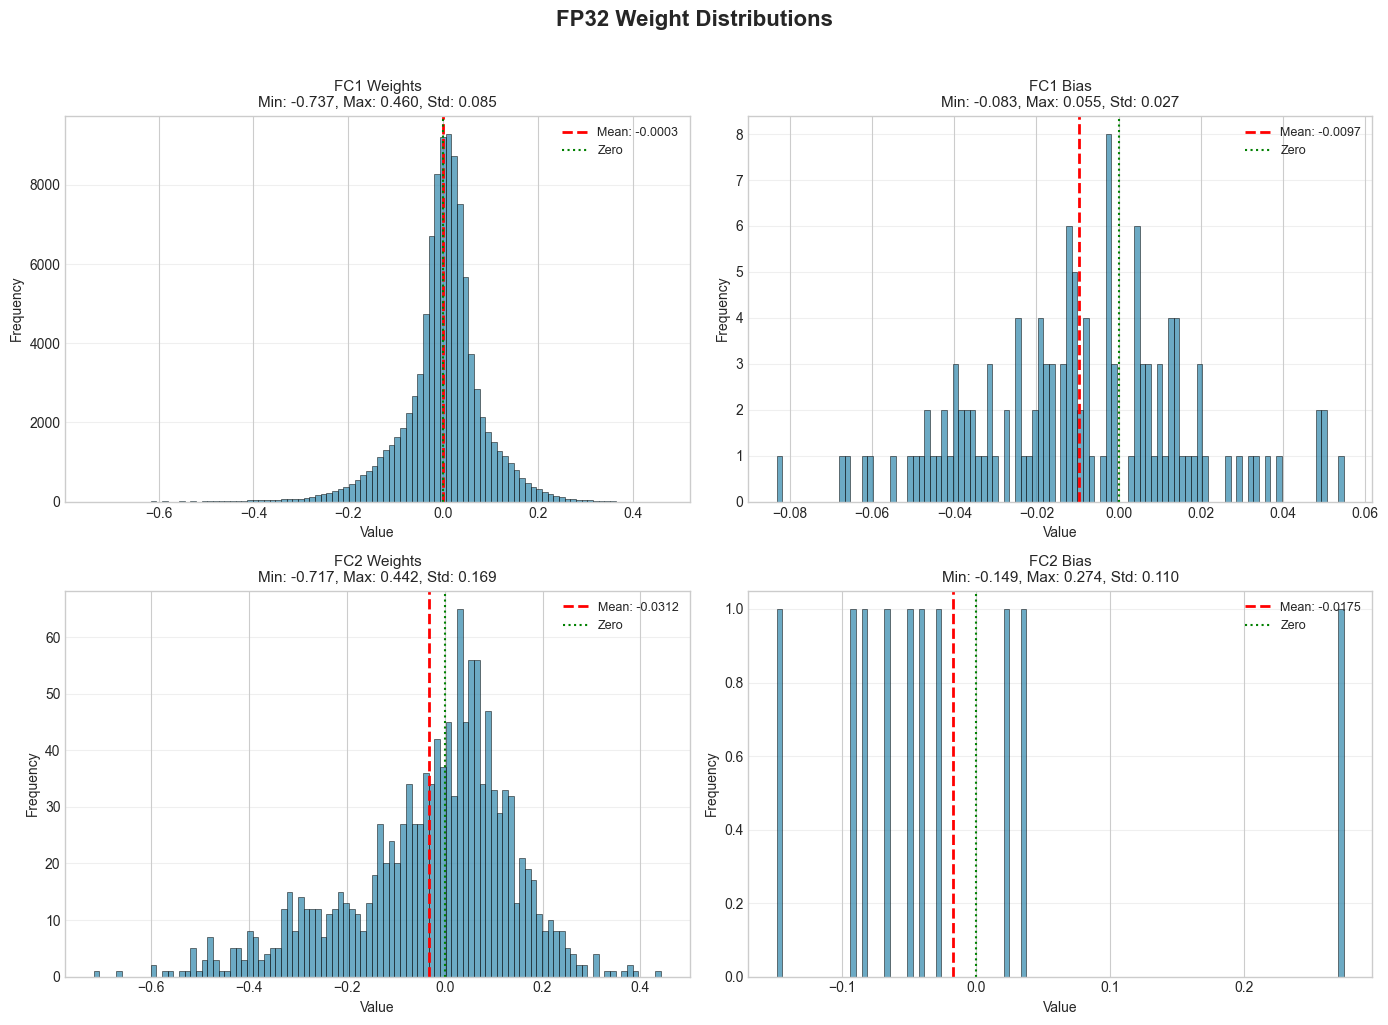

In [5]:
"""
Visualize weight distributions before and after quantization.
"""

# Load weights
weights_fp32 = np.load(f'{RESULTS_DIR}/float32/weights.npy', allow_pickle=True).item()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

weight_names = ['fc1_weight', 'fc1_bias', 'fc2_weight', 'fc2_bias']
titles = ['FC1 Weights', 'FC1 Bias', 'FC2 Weights', 'FC2 Bias']

for idx, (name, title) in enumerate(zip(weight_names, titles)):
    ax = axes[idx // 2, idx % 2]
    
    w = weights_fp32[name].flatten()
    
    # Plot histogram
    ax.hist(w, bins=100, alpha=0.7, color='#2E86AB', edgecolor='black', linewidth=0.5)
    
    # Add statistics
    ax.axvline(w.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {w.mean():.4f}')
    ax.axvline(0, color='green', linestyle=':', linewidth=1.5, label='Zero')
    
    ax.set_xlabel('Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{title}\nMin: {w.min():.3f}, Max: {w.max():.3f}, Std: {w.std():.3f}', 
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('FP32 Weight Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/weight_distribution_fp32.png', dpi=150, bbox_inches='tight')
plt.show()

## 5: Quantization Error Analysis

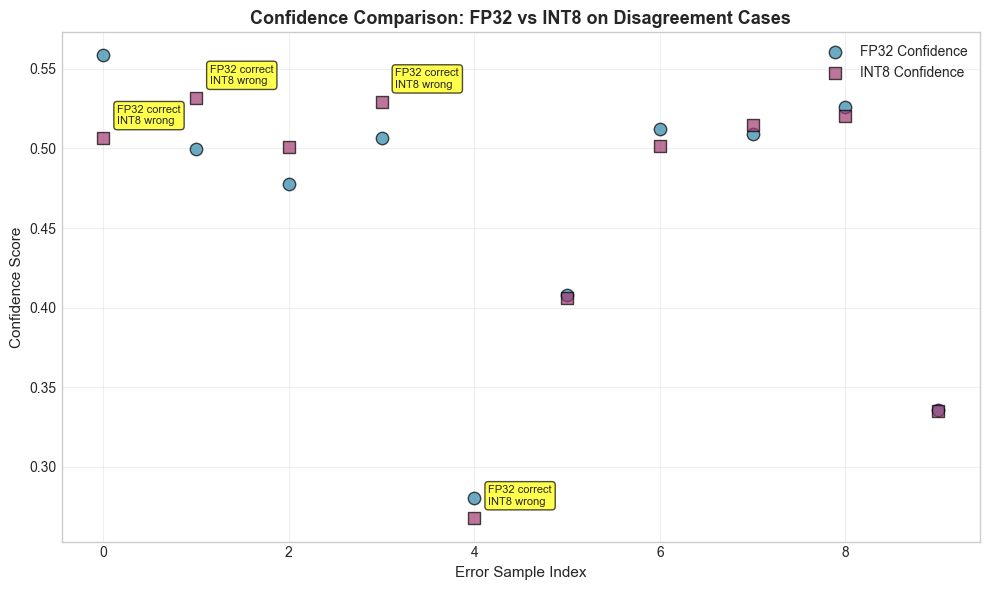

In [6]:
"""
Analyze quantization error: difference between FP32 and INT8 predictions.
"""

errors = metrics_int8_sym.get('error_examples', [])

if errors:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Extract confidence scores
    fp32_confs = [e['fp32_conf'] for e in errors]
    int8_confs = [e['int8_conf'] for e in errors]
    
    x = range(len(errors))
    
    ax.scatter(x, fp32_confs, label='FP32 Confidence', color='#2E86AB', s=80, alpha=0.7, edgecolors='black')
    ax.scatter(x, int8_confs, label='INT8 Confidence', color='#A23B72', s=80, alpha=0.7, edgecolors='black', marker='s')
    
    # Highlight cases where INT8 is overconfident and wrong
    for i, e in enumerate(errors):
        if e['fp32_pred'] == e['true'] and e['int8_pred'] != e['true']:
            ax.annotate(f"FP32 correct\nINT8 wrong", 
                       xy=(i, int8_confs[i]), 
                       xytext=(10, 10), 
                       textcoords='offset points',
                       fontsize=8,
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
    
    ax.set_xlabel('Error Sample Index', fontsize=11)
    ax.set_ylabel('Confidence Score', fontsize=11)
    ax.set_title('Confidence Comparison: FP32 vs INT8 on Disagreement Cases', 
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{PLOTS_DIR}/confidence_comparison_errors.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No error examples found in metrics.")

## 6: Activation Range Analysis

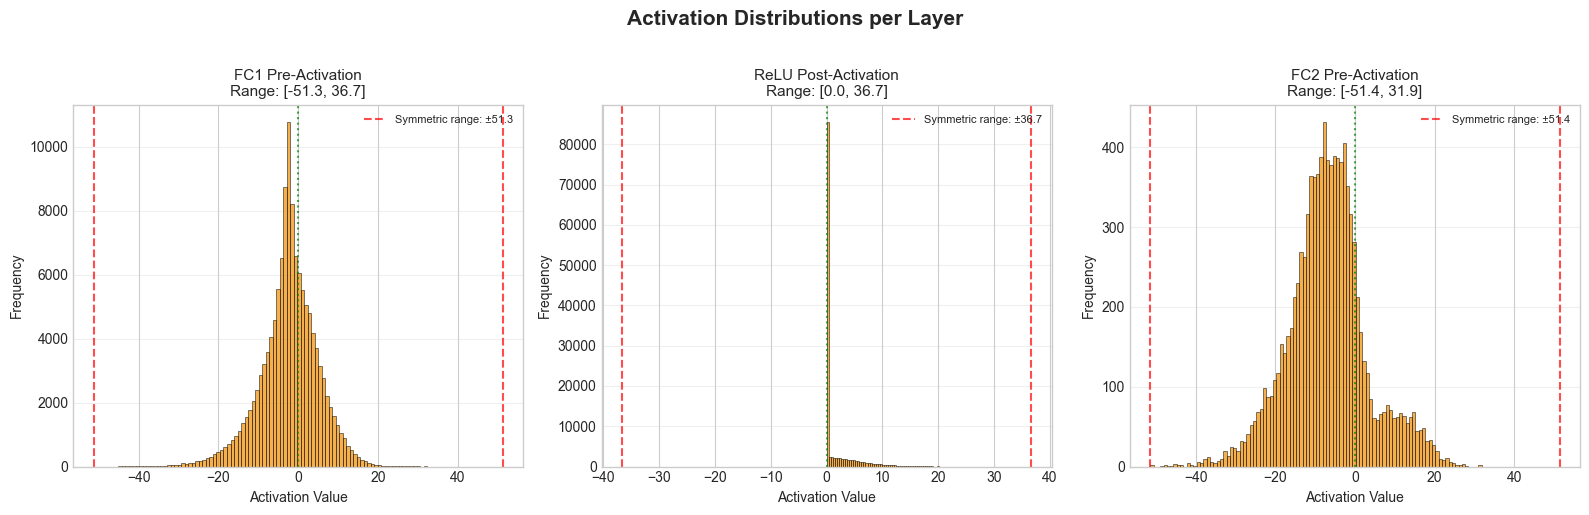

In [7]:
"""
Visualize activation ranges per layer to understand why quantization works (or fails).
"""

activations_fp32 = np.load(f'{RESULTS_DIR}/float32/activations.npy', allow_pickle=True).item()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

layer_names = ['fc1', 'relu', 'fc2']
titles = ['FC1 Pre-Activation', 'ReLU Post-Activation', 'FC2 Pre-Activation']

for idx, (name, title) in enumerate(zip(layer_names, titles)):
    ax = axes[idx]
    a = activations_fp32[name]
    
    # Histogram
    ax.hist(a, bins=100, alpha=0.7, color='#F18F01', edgecolor='black', linewidth=0.5)
    
    # Mark symmetric range that would be used
    abs_max = np.max(np.abs(a))
    ax.axvline(-abs_max, color='red', linestyle='--', alpha=0.7, label=f'Symmetric range: ±{abs_max:.1f}')
    ax.axvline(abs_max, color='red', linestyle='--', alpha=0.7)
    
    # Mark zero
    ax.axvline(0, color='green', linestyle=':', linewidth=1.5, alpha=0.7)
    
    ax.set_xlabel('Activation Value', fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{title}\nRange: [{a.min():.1f}, {a.max():.1f}]', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Activation Distributions per Layer', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/activation_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

## 7: Scale and Zero-Point Analysis

In [8]:
"""
Display quantization parameters (scales, zero-points) for each layer.
"""

# This requires running quantize.py to extract scales, or computing them here
# For demonstration, compute from saved weights

weights_fp32 = np.load(f'{RESULTS_DIR}/float32/weights.npy', allow_pickle=True).item()

print("=" * 60)
print("QUANTIZATION PARAMETERS (Symmetric)")
print("=" * 60)

for name in ['fc1_weight', 'fc2_weight']:
    w = weights_fp32[name]
    qmin, qmax = -127, 127
    scale = np.max(np.abs(w)) / qmax
    
    print(f"\n{name}:")
    print(f"  FP32 range: [{w.min():.4f}, {w.max():.4f}]")
    print(f"  Scale: {scale:.6f}")
    print(f"  Quantized range: [{int(w.min() / scale)}, {int(w.max() / scale)}]")
    print(f"  Effective precision: ~{scale:.6f} per INT8 step")

print("\n" + "=" * 60)
print("OBSERVATION: Smaller scale = finer precision, but requires")
print("careful handling of activations with wide dynamic range.")
print("=" * 60)

QUANTIZATION PARAMETERS (Symmetric)

fc1_weight:
  FP32 range: [-0.7369, 0.4601]
  Scale: 0.005802
  Quantized range: [-127, 79]
  Effective precision: ~0.005802 per INT8 step

fc2_weight:
  FP32 range: [-0.7168, 0.4423]
  Scale: 0.005644
  Quantized range: [-127, 78]
  Effective precision: ~0.005644 per INT8 step

OBSERVATION: Smaller scale = finer precision, but requires
careful handling of activations with wide dynamic range.
